# Import packages

In [2]:
.libPaths('/home/lixinxing/anaconda3/envs/my_monocle3_2/lib/R/library')

In [14]:
library(rvest)
library(tidyverse)
library(clusterProfiler)
library(RColorBrewer)
library("circlize")
library(dplyr)
library(ggplot2)
library(stringr)

# Prepare KEGG pathway gene sets

In [7]:
hsa <- read.delim('https://rest.kegg.jp/list/pathway/hsa', sep = "\t", 
                  col.names = c('ID', 'Name')) %>%
  mutate(Name = str_replace(Name, ' - Homo sapiens \\(human\\)', ''))

gene_info <- read.delim('https://rest.kegg.jp/list/hsa', sep = '\t') %>%
  dplyr::select(1, 4) %>%
  rename_with(~ c('hsa', 'info')) %>%
  mutate(symbol = str_extract(info, "(^[\\w-]+)[;,]", group = 1))

pathway <- read.delim('https://rest.kegg.jp/link/pathway/hsa', sep = '\t', 
                      col.names = c('hsa', 'ID')) %>%
  mutate(ID = str_remove(ID, 'path:')) %>%
  inner_join(hsa) %>%
  inner_join(gene_info) %>%
  dplyr::select(c('Name', 'symbol'))

write.csv(pathway, "./kegg_pathway.csv", row.names = FALSE)

Joining with `by = join_by(ID)`
Joining with `by = join_by(hsa)`


In [4]:
kegg.pathway=read.csv('/home/lixinxing/IBD/data_sc/soupX/soupX_new/kegg_pathway.csv')
kegg.pathway

Name,symbol
<chr>,<chr>
Glycolysis / Gluconeogenesis,ADH1A
Glycolysis / Gluconeogenesis,ADH1B
Glycolysis / Gluconeogenesis,ADH1C
Glycolysis / Gluconeogenesis,ADH4
Glycolysis / Gluconeogenesis,ADH5
Glycolysis / Gluconeogenesis,ADH6
Glycolysis / Gluconeogenesis,GALM
Glycolysis / Gluconeogenesis,ADH7
Glycolysis / Gluconeogenesis,LDHAL6A


In [10]:
url <- 'https://www.kegg.jp/kegg/pathway.html'
html <- read_html(url)

hsa <- data.frame(class = character(),
                  subclass = character(),
                  ID = character(),
                  name = character(),
                  stringsAsFactors = FALSE)
metabolism_section <- html %>% html_nodes(css = "#metabolism, #metabolism ~ b, #metabolism ~ h4")

cate <- NA
subcate <- NA

for (node in metabolism_section) {
  tag <- html_name(node)
  if (tag == 'h4') {
    cate <- str_trim(str_split(html_text(node), ' ', simplify = TRUE)[, 2])
  } else if (tag == 'b') {
    subcate <- str_trim(str_extract(html_text(node), '(?<=\\s).+'))
    entries <- html_elements(
      html_element(node, xpath = "following-sibling::div[1]"), "dt, a")
    for (entry in entries) {
      entry_text <- html_text(entry, trim = TRUE)
      if (str_detect(entry_text, "^\\d{5}")) {
        entry_text <- str_extract(entry_text, "^(\\d+)", group = 1)
        hsa <- rbind(hsa, data.frame(
          class = cate,
          subclass = subcate,
          ID = paste0("hsa", entry_text),
          name = NA, stringsAsFactors = FALSE))
      } else if (!is.na(entry_text) && nrow(hsa) > 0
                 && is.na(hsa$name[nrow(hsa)])) {
        hsa$name[nrow(hsa)] <- entry_text
      }
    }
  } else {
    stop('Unexpected value of ', tag)
  }
}

write.csv(hsa, "kegg_category.csv", row.names = FALSE)

In [5]:
kegg.category=read.csv('/home/lixinxing/IBD/data_sc/soupX/soupX_new/kegg_category.csv')
kegg.category

class,subclass,ID,name
<chr>,<chr>,<chr>,<chr>
Metabolism,Global and overview maps,hsa01100,Metabolic pathways
Metabolism,Global and overview maps,hsa01110,Biosynthesis of secondary metabolites
Metabolism,Global and overview maps,hsa01120,Microbial metabolism in diverse environments
Metabolism,Global and overview maps,hsa01200,Carbon metabolism
Metabolism,Global and overview maps,hsa01210,2-Oxocarboxylic acid metabolism
Metabolism,Global and overview maps,hsa01212,Fatty acid metabolism
Metabolism,Global and overview maps,hsa01230,Biosynthesis of amino acids
Metabolism,Global and overview maps,hsa01232,Nucleotide metabolism
Metabolism,Global and overview maps,hsa01250,Biosynthesis of nucleotide sugars


# Enrichment analysis of macrophage subtypes

In [50]:
markers1=read.csv('/home/lixinxing/IBD/data_sc/soupX/soupX_new/seurat/Mye_subtype_marker.csv')
markers1=markers1[markers1$log_fold_changes>0,]

markers2=markers1[markers1$p_adj<0.05,]
markers3=markers2[markers2$log_fold_changes>1.5,]

df=markers3[c('group','genes')]
colnames(df)=c('Group','Gene')
entrez_genes=bitr(df$Gene,fromType = 'SYMBOL',toType = 'ENTREZID',OrgDb = 'org.Hs.eg.db')
mix=merge(df,entrez_genes,by.x='Gene',by.y='SYMBOL')

# de_gene_clusters=data.frame(ENTREZID=mix$ENTREZID,cluster=mix$Group)
de_gene_clusters=data.frame(ENTREZID=mix$Gene,cluster=mix$Group)

de_gene_clusters=de_gene_clusters[de_gene_clusters$cluster %in% c('C1Q+ TR-Macro','MERTK+ Macro','FCN1+ inf-Macro','TNF+ Macro'),]
de_gene_clusters

,ENTREZID,cluster
,<chr>,<chr>
4,A2M,MERTK+ Macro
10,AAK1,MERTK+ Macro
13,AARS2,MERTK+ Macro
15,ABCA1,MERTK+ Macro
16,ABCA1,TNF+ Macro
29,ABCC3,MERTK+ Macro
31,ABCC4,MERTK+ Macro
33,ABCC5,MERTK+ Macro
39,ABCG1,MERTK+ Macro


In [9]:
options(repr.plot.width=16,repr.plot.height=12)

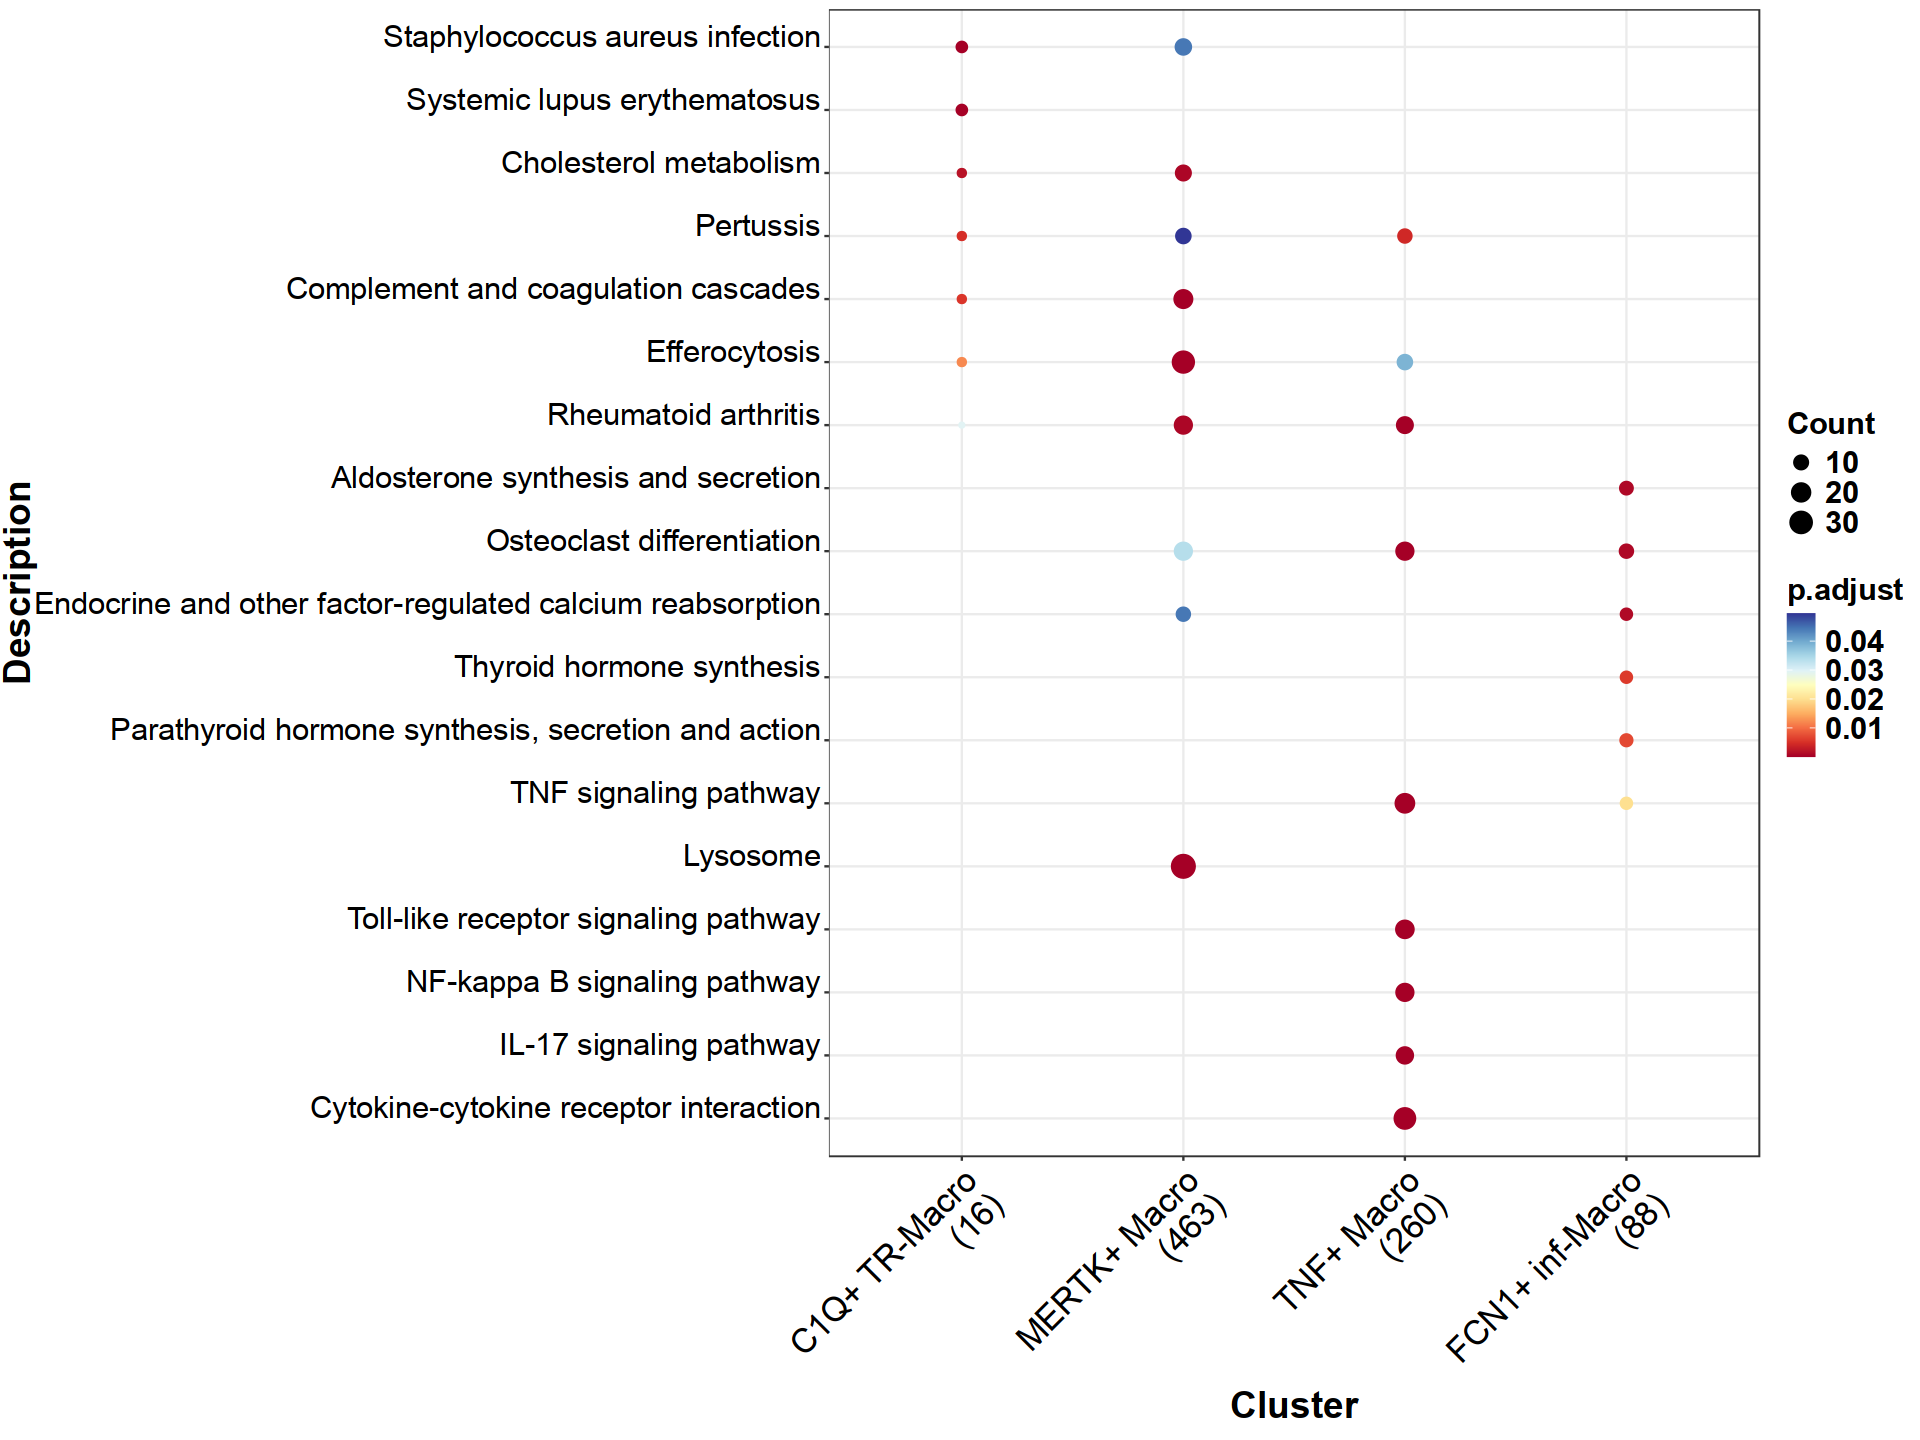

In [55]:
x=compareCluster(ENTREZID~cluster,data = de_gene_clusters,
                 fun = 'enricher',
                 TERM2GENE=kegg.pathway
)

x@compareClusterResult$Cluster <- factor(
  x@compareClusterResult$Cluster,
  levels = c("C1Q+ TR-Macro", "MERTK+ Macro", "TNF+ Macro", "FCN1+ inf-Macro")
)

colors <- rev(colorRampPalette(rev(brewer.pal(n = 11, name = "RdYlBu")))(100))
values <- seq(0, 0.05, length.out = 101)[-101]  
col_fun <- colorRamp2(values, colors)  

p<-ggplot(x,aes(Cluster,Description))+
  geom_point(aes(size=Count,color=p.adjust))+
  # scale_color_gradientn(colours=c('#b3eebe', "#46bac2", '#371ea3'),
  #                       guide=guide_colorbar(reverse=TRUE))+
 scale_color_gradientn(colors = col_fun(values)) + 
 theme_bw()+
   theme(plot.title = element_text(size = 25, colour = "black", hjust = 0.5),
          axis.title.y = element_text(size = 22, color = "black", face = "bold", vjust = 1.9, hjust = 0.5, angle = 90),
          axis.title.x = element_text(size = 22, color = "black", face = "bold", vjust = 1.9, hjust = 0.5, angle = 0),
          legend.title = element_text(color="black", size=18, face="bold"),
          legend.text = element_text(color="black", size = 18, face = "bold"),
          strip.text = element_text(size = 18, face = "bold", margin = margin(t = 7, b = 7, l = 7, r = 7)),  # 增加分面标签的边距
          strip.background = element_rect(fill = "#d9d9d9", colour = "#d9d9d9"),  
          axis.text.x = element_text(size = 20, color = "black", vjust = 1, hjust = 1, angle = 45),
          axis.text.y = element_text(size = 18, color = "black",vjust = 0, hjust = 1, angle = 0))
p
# ggsave('./Myeloid_celltype_kegg.pdf',width = 16,height = 12)